<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [7]:
import sys
sys.path.extend(['/Users/fzheng/SkyDrive/Codes/Python/Pyramid']) # where Pyramid situates
print('Python %s on %s' % (sys.version, sys.platform))

Python 3.5.6 |Anaconda, Inc.| (default, Jun  4 2021, 13:57:47) 
[GCC 7.5.0] on linux


In [8]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import hyperspy as hs
import pyramid as pr
import os
from tqdm import tqdm_notebook as tqdm
from scipy.ndimage import gaussian_filter
pr.plottools.pretty_plots()

In [9]:
# pathname = '/Users/fzheng/sciebo/TargetSkyrmion/3Dcom/'
pathname = './sim_SD'
#filename = 'magdata_rec_lam1e-01-mask'
filename = '/m_00003817'
path = pathname + filename

In [10]:
magdata = pr.load_vectordata('{}.ovf'.format(path))
#magdata.plot_quiver_field(ar_dens=4)
#magdata.save('{}2.vtk'.format(path))

In [11]:
# magdata = magdata.rotate(-120,axis='z') 
# magdata = magdata.rotate(8,axis='x') 
# magdata = magdata.rotate(0,axis='y')

In [12]:
print(magdata.dim)

(110, 136, 136)


In [13]:
plot = False
angle = (0+180,180-28,180-44,180-50,180-54,180-58,180-61,180-65)
angles = np.deg2rad(angle)

#phasemap = pr.utils.pm(magdata)
#if plot:
#    phasemap.plot_combined()

# %% [markdown]
# # Create projectors:
# %%
projectors = []
dim_uv = (magdata.dim[2] + 54, magdata.dim[1] + 54)
for angle in tqdm(angles):
    projectors.append(pr.XTiltProjector(magdata.dim, angle, dim_uv))

# %% [markdown]
# # Create phasemaps:
# %%
phasemaps = []
for projector in projectors:
    mag_proj = projector(magdata)
    phasemap = pr.PhaseMapperRDFC(pr.Kernel(magdata.a, projector.dim_uv))(mag_proj)
    phasemap.mask = mag_proj.get_mask()[0, ...]
    #phasemap.phase = gaussian_filter(phasemap.phase, sigma=3)
    phasemaps.append(phasemap)
    #phasemap.save('phase_{}.txt'.format(np.rad2deg(projector.tilt)))

# %% [markdown]
# # Create dataset:
# %%
data = pr.DataSet(magdata.a, magdata.dim)
data.append(phasemaps, projectors)
if plot:
    data.plot_phasemaps_combined(gain=20)

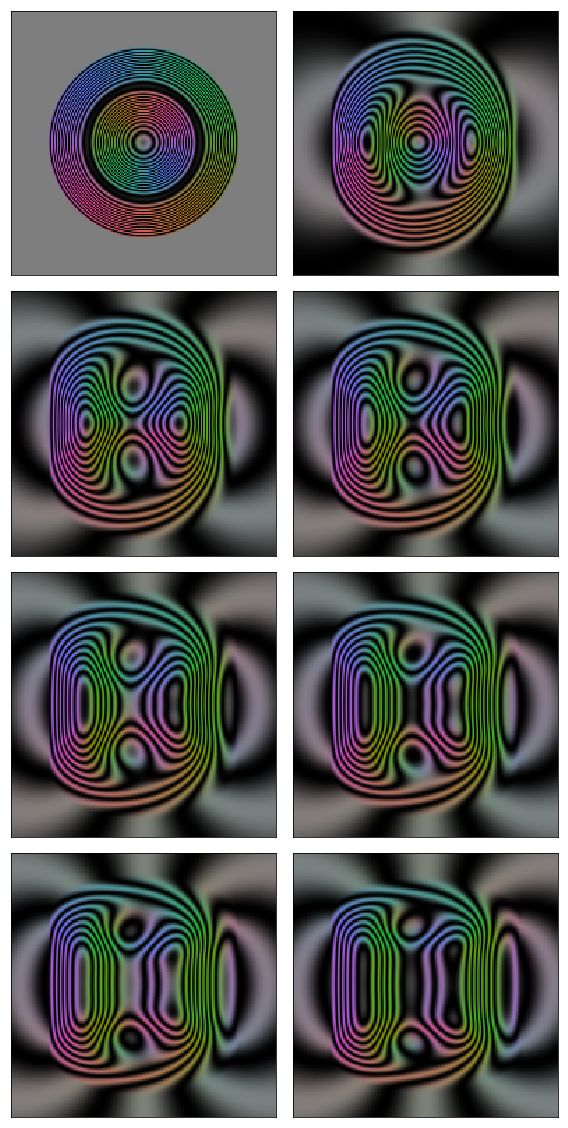

In [14]:
fig = plt.figure(figsize=(8,16))
ax = {}

for i in np.arange(0,8,1):
    
    tilt = np.round_(np.rad2deg(projectors[i].tilt))
    ax[i+1] = fig.add_subplot(4, 2, i+1, aspect='equal')
    ax[i+1].get_xaxis().set_visible(False)
    ax[i+1].get_yaxis().set_visible(False)
    phasemaps[i].phase = - phasemaps[i].phase
    phasemaps[i].plot_holo(axis=ax[i+1],gain=20,scalebar=False,colorwheel=False,note='')
    plt.tight_layout(h_pad=0.4)

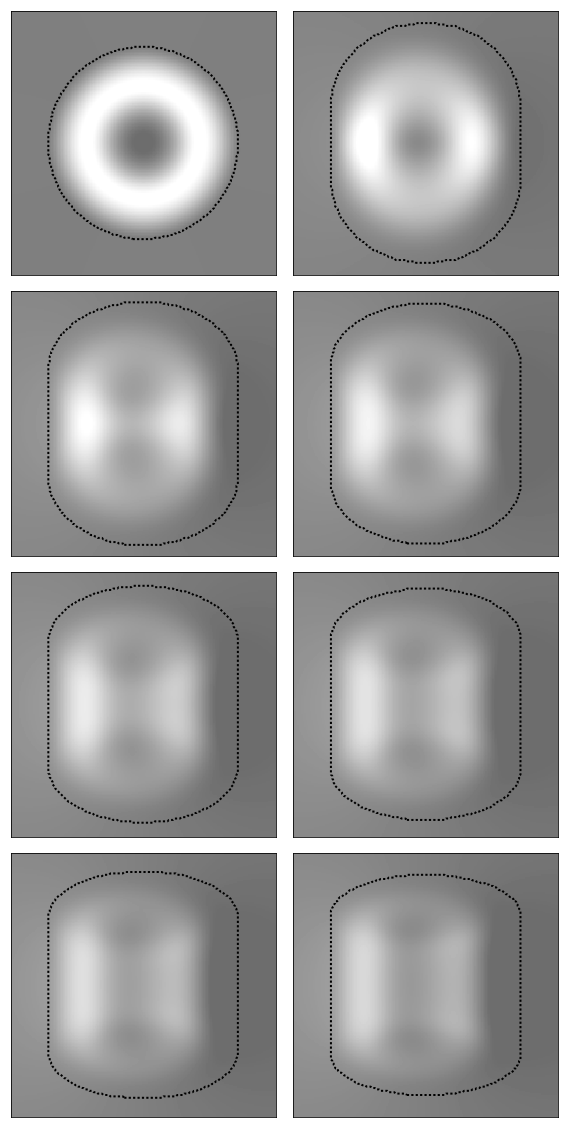

In [15]:
fig = plt.figure(figsize=(8,16))
ax = {}

for i in np.arange(0,8,1):
    
    tilt = np.round_(np.rad2deg(projectors[i].tilt))
    ax[i+1] = fig.add_subplot(4, 2, i+1, aspect='equal')
    ax[i+1].get_xaxis().set_visible(False)
    ax[i+1].get_yaxis().set_visible(False)
    #phasemaps[i].phase = - phasemaps[i].phase
    phasemaps[i].plot_phase(axis=ax[i+1],scalebar=False,note=" ",cbar=False,cmap='gray', vmin=-0.5, vmax=3.5)
    plt.tight_layout(h_pad=0.4)

In [16]:
phasemap.dim_uv

(190, 190)